In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import gamma as gam
import torch
from scipy.optimize import minimize
import emcee
import sys
# sys.path.append("..")
# from src.dataset import SIRModel

# Stochastic Model

In [27]:
N = 100
T = 52
X = np.zeros((T, N))
Y = np.zeros((T, N))
beta = .3
gamma = .1
# X[0, 0] = 1 # seed initial infected patient

X[0][:2] = 1

obs_seed = 9

In [30]:
# frequency dependent: divide force of infection by N
# to do: negative binomial noise for observed cases
np.random.seed(obs_seed)

for t in range(1, T):
    S = (1 - X[t-1]) * (1 - Y[t-1])
    I = X[t-1] * (1 - Y[t-1])

    # simulate infections
    lam = beta * I.sum() / N
    p_i = 1 - np.exp(-lam)
    X[t] = np.where(S, np.random.binomial(1, p_i, N), X[t-1])

    # observational noise?
    
    # simulate recoveries
    p_r = 1 - np.exp(-gamma)
    Y[t] = np.where(I, np.random.binomial(1, p_r, N), Y[t-1])

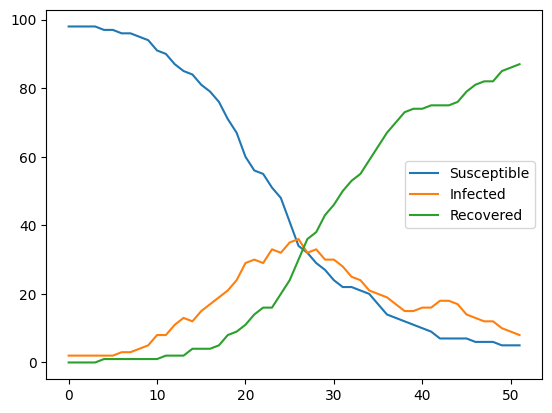

In [31]:
S = N - X.sum(1)
I = X.sum(1) - Y.sum(1)
R = Y.sum(1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.plot(R, label="Recovered")
plt.legend()
plt.show()

# Likelihood-based Inference (MCMC)

In [94]:
prior_scale = [0.1, 0.1]

In [95]:
def log_prior(theta):
    if (theta <= 0).any():
        return -np.inf
    else:
        return gam(1, scale=prior_scale).logpdf(theta)

In [99]:
def log_likelihood(beta, gamma, X, Y):
    ans = 0
    T = X.shape[0]
    for t in range(1, T):
        S = (1 - X[t-1]) * (1 - Y[t-1])
        I = X[t-1] * (1 - Y[t-1])
        lam = beta * I.sum() / N
        ans += (
            S * X[t] * np.log(1 - np.exp(-lam))
        ).sum()
        ans += (
            S * (1 - X[t]) * -lam 
        ).sum()
        ans += (
            I * Y[t] * np.log(1 - np.exp(-gamma))
        ).sum()
        ans += (
            I * (1 - Y[t]) * -gamma
        ).sum()
    return ans

## MLE

In [61]:
def f(theta, X, Y):
    beta, gamma = theta
    return - log_likelihood(X, Y, beta, gamma)

In [62]:
mle = minimize(f, x0=[0.1, 0.1], args = (X, Y), bounds=((0, None), (0, None)))

In [63]:
mle.x

array([0.29137038, 0.10626214])

## MCMC

In [100]:
def log_prob(theta, X, Y):
    lp = log_prior(theta)
    beta, gamma = theta
    return lp + log_likelihood(beta, gamma, X, Y)

In [105]:
nwalkers = 8
pos = np.array(prior_scale) + 1e-3 * np.random.randn(nwalkers, 2)
sampler = emcee.EnsembleSampler(
    nwalkers, 2, log_prob, args = (X, Y)
)
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████████████████████████████████| 2000/2000 [00:14<00:00, 140.30it/s]


State([[0.24149261 0.10636332]
 [0.23963977 0.10228645]
 [0.33496707 0.10582533]
 [0.24795441 0.10774742]
 [0.29455246 0.09968279]
 [0.32254595 0.08983473]
 [0.29686388 0.10097269]
 [0.27963029 0.10661278]], log_prob=[-644.13054791 -644.29923241 -644.47244975 -643.81040287 -643.29972141
 -645.05724766 -643.2712225  -643.04919348], blobs=[-642.77925496 -642.92569914 -642.18103238 -642.40833297 -641.35102475
 -642.73013551 -641.31231053 -641.31901834], random_state=('MT19937', array([3621007236, 3049800956,  815181079,  598469343,  980685623,
       3327419686, 1426787718, 3240705651, 2809095066, 2851182069,
        582708071, 2588690223, 3503685282,  698240558,   25929057,
       3045885512, 3147781843, 1363680810, 3209545772, 2745429575,
        799849750, 1919887967, 2817319370, 2822495659, 3716102630,
       2886027322, 1326204352,  306023007, 3547569176, 2175322515,
       2340606113, 2178717518, 3738118918, 3592371265, 2171236742,
         22709788, 2368794711,  945406301, 31849943

In [106]:
flat_samples = sampler.get_chain(discard=100, thin=50, flat=True)
flat_samples.mean(0)

array([0.28650246, 0.10736832])

In [107]:
flat_samples.std(0)

array([0.03110454, 0.01160666])

In [112]:
np.corrcoef(flat_samples.T)

array([[1.        , 0.06748697],
       [0.06748697, 1.        ]])

# Prior

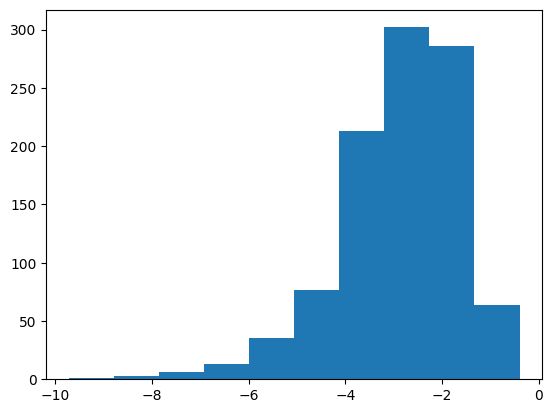

In [118]:
plt.hist(np.log(gam(1, scale=0.1).rvs(1000)))
plt.show()

In [124]:
np.exp(-2.25)

np.float64(0.10539922456186433)